In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import umap

# EMB_PATH = "/home/adickson/rice_data/sativas413_embeddings.pt"
# EMB_PATH = "/home/andrew.dickson/svar/sativas413_embeddings_snponly.pt"
EMB_PATH = "/home/andrew.dickson/svar/sativas413_embeddings.pt"



In [3]:
data = torch.load(EMB_PATH, weights_only=True)
embeddings  = data["embeddings"].float().numpy()   # (413, 768)
sample_ids  = data["sample_ids"]

print(f"{embeddings.shape[0]} samples  ×  {embeddings.shape[1]} dims")

413 samples  ×  768 dims


In [6]:
# BERT embeddings live in a narrow cone — subtract the mean to remove that constant
# direction before any analysis, otherwise PC1 captures ~100% of variance trivially.
embeddings_centered = embeddings - embeddings.mean(axis=0)

In [7]:
# ── Embedding variance diagnostic ──────────────────────────────────────────────
# If SNPs weren't incorporated, all sample embeddings will be nearly identical
# (differing only by floating-point noise). These numbers distinguish that from
# genuine but low-dimensional variation.

per_dim_std = embeddings_centered.std(axis=0)          # std across samples per dim
mean_l2     = np.linalg.norm(embeddings_centered, axis=1).mean()  # mean L2 from centroid

# Sample 200 random pairs and compute L2 distances
rng  = np.random.default_rng(0)
idx  = rng.integers(0, len(embeddings_centered), size=(200, 2))
pair_dists = np.linalg.norm(
    embeddings_centered[idx[:, 0]] - embeddings_centered[idx[:, 1]], axis=1
)

print(f"Per-dim std  — mean: {per_dim_std.mean():.5f}  max: {per_dim_std.max():.5f}")
print(f"Mean L2 from centroid : {mean_l2:.5f}")
print(f"Pairwise L2 — mean: {pair_dists.mean():.5f}  max: {pair_dists.max():.5f}")
print()
print("Interpretation:")
print("  If pairwise L2 ≈ 0 → embeddings are identical → SNPs not being applied")
print("  If pairwise L2 > 0 but small → SNPs applied but window context dominates")

Per-dim std  — mean: 0.00004  max: 0.00317
Mean L2 from centroid : 0.00291
Pairwise L2 — mean: 0.00388  max: 0.01167

Interpretation:
  If pairwise L2 ≈ 0 → embeddings are identical → SNPs not being applied
  If pairwise L2 > 0 but small → SNPs applied but window context dominates


In [8]:
embeddings_centered = embeddings_centered * 1e3

/local/scratch/andrew.dickson/19629663/ipykernel_201473/3771765681.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='tab10', s=15)


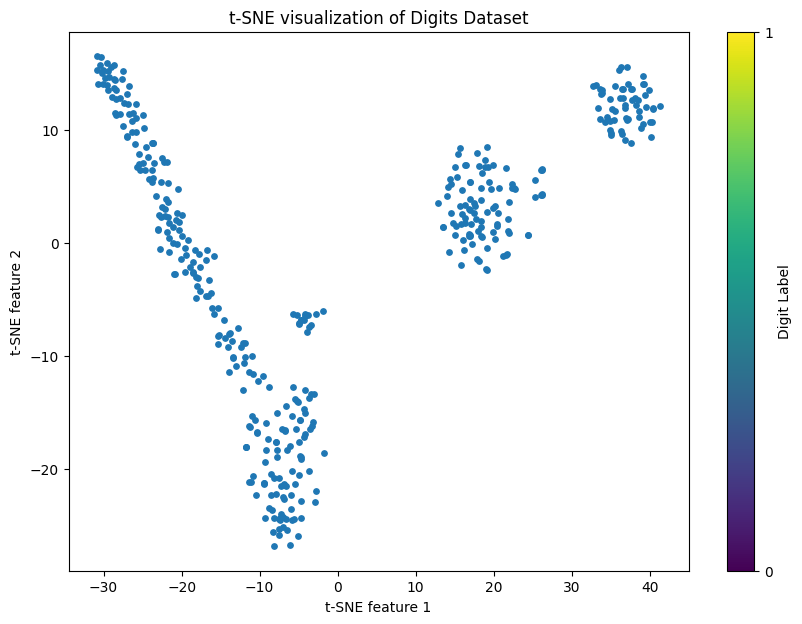

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(embeddings_centered)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

# Plot the results
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_embedded[:, 0], X_embedded[:, 1], cmap='tab10', s=15)
plt.title("t-SNE visualization of Digits Dataset")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.show()


In [14]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
from pathlib import Path
from sklearn.preprocessing import StandardScaler

VCF_PATH      = Path("../rice_data/sativas413_msu7_final.vcf")
PHENO_PATH    = Path("../rice_data/RiceDiversity_44K_Phenotypes_34traits_PLINK.txt")

def load_vcf_sparse(vcf_path: Path):
    """
    Parse a biallelic, homozygous VCF into a sparse binary matrix.

    Returns
    -------
    X        : scipy.sparse.csr_matrix, shape (n_samples, n_snps), uint8
    samples  : list[str]  – VCF sample IDs (column headers after FORMAT)
    snp_ids  : list[str]  – SNP IDs from the ID column
    n_missing: int        – total ./. calls (encoded as 0)
    """
    samples, snp_ids = [], []
    rows, cols = [], []   # coordinates of alt-allele calls (value=1)
    n_missing = 0

    # GT token → integer: "0/0"→0, "1/1"→1, "./."→0
    _gt_map = {"0/0": 0, "1/1": 1, "./.": 0, '0/1': 0.5}

    with open(vcf_path) as fh:
        for line in fh:
            if line.startswith("##"):
                continue

            fields = line.rstrip("\n").split("\t")

            if line.startswith("#CHROM"):
                # columns 9+ are sample IDs
                samples = fields[9:]
                continue

            snp_idx = len(snp_ids)
            snp_ids.append(fields[2])   # ID column

            gts = fields[9:]
            for samp_idx, gt in enumerate(gts):
                val = _gt_map.get(gt, 0)
                if gt == "./.":
                    n_missing += 1
                if val == 1:
                    rows.append(samp_idx)
                    cols.append(snp_idx)

    n_samples = len(samples)
    n_snps    = len(snp_ids)

    X = sp.csr_matrix(
        (np.ones(len(rows), dtype=np.uint8), (rows, cols)),
        shape=(n_samples, n_snps),
        dtype=np.uint8,
    )
    return X, samples, snp_ids, n_missing


X_vcf, vcf_samples, snp_ids, n_missing = load_vcf_sparse(VCF_PATH)

print(f"Shape (samples × SNPs) : {X_vcf.shape}")
print(f"Stored non-zeros       : {X_vcf.nnz:,}  ({100*X_vcf.nnz/X_vcf.shape[0]/X_vcf.shape[1]:.1f}% density)")
print(f"Missing genotypes (./.): {n_missing:,}")
print(f"Memory (sparse)        : {X_vcf.data.nbytes / 1e6:.1f} MB")
print(f"\nFirst 5 sample IDs: {vcf_samples[:5]}")
print(f"First 5 SNP IDs   : {snp_ids[:5]}")

Shape (samples × SNPs) : (413, 36900)
Stored non-zeros       : 3,647,606  (23.9% density)
Missing genotypes (./.): 660,749
Memory (sparse)        : 3.6 MB

First 5 sample IDs: ['081215-A05_1', '081215-A06_3', '081215-A07_4', '081215-A08_5', '090414-A09_6']
First 5 SNP IDs   : ['id1000001', 'id1000003', 'id1000005', 'id1000007', 'id1000008']


In [16]:
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Reduce dimensionality with TruncatedSVD (works natively on sparse matrices)
# Use 120 components — fast, keeps most variance for a quick sanity check
print("Fitting TruncatedSVD (120 components) on sparse SNP matrix...")
svd = TruncatedSVD(n_components=120, random_state=42)
X_svd = svd.fit_transform(X_vcf)   # (n_samples, 120)
print(f"Explained variance ratio (first 10 components): "
      f"{svd.explained_variance_ratio_[:10].round(3)}")
print(f"Total variance explained: {svd.explained_variance_ratio_.sum():.3f}")

Fitting TruncatedSVD (120 components) on sparse SNP matrix...
Explained variance ratio (first 10 components): [0.298 0.105 0.082 0.061 0.023 0.015 0.012 0.01  0.009 0.008]
Total variance explained: 0.864


/local/scratch/andrew.dickson/19629663/ipykernel_201473/882737541.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_embedded_svd[:, 0], X_embedded_svd[:, 1], cmap='tab10', s=15)


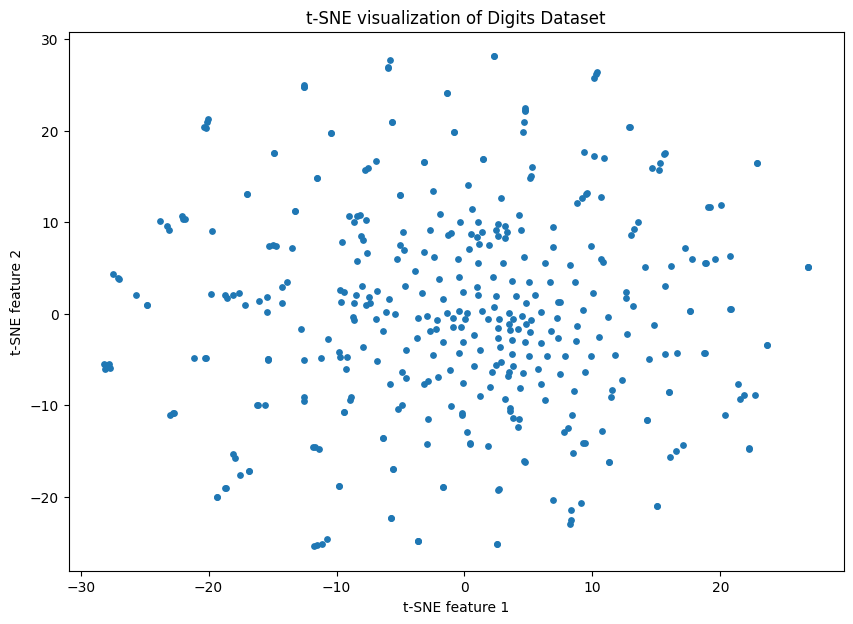

In [18]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
X_scaled_svd = StandardScaler().fit_transform(X_svd)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_embedded_svd = tsne.fit_transform(X_scaled_svd)

# Plot the results
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_embedded_svd[:, 0], X_embedded_svd[:, 1], cmap='tab10', s=15)
plt.title("t-SNE visualization of Digits Dataset")
plt.xlabel("t-SNE feature 1")
plt.ylabel("t-SNE feature 2")
plt.show()


In [ ]:
reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.01)
coords  = reducer.fit_transform(X_scaled)
print("UMAP done:", coords.shape)


/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done: (413, 2)


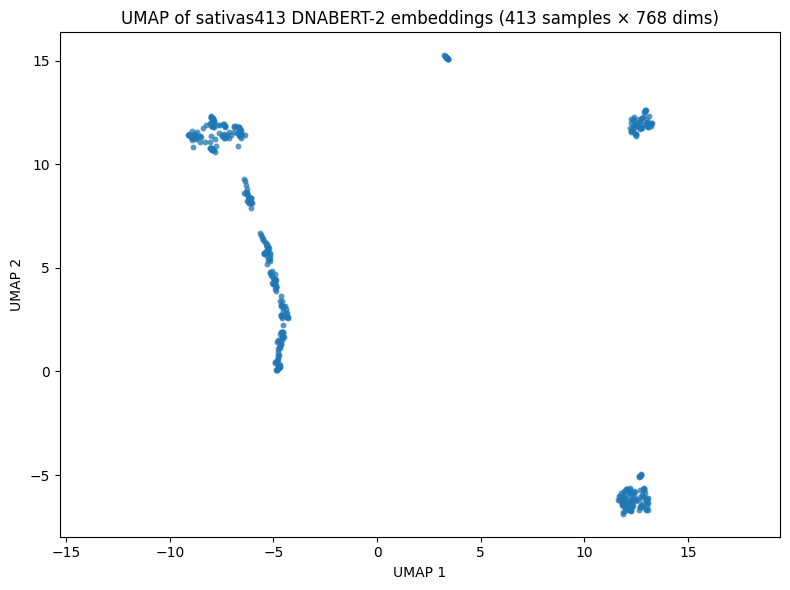

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

sc = ax.scatter(coords[:, 0], coords[:, 1], s=18, alpha=0.75, linewidths=0)

ax.set_title("UMAP of sativas413 DNABERT-2 embeddings (413 samples × 768 dims)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_aspect("equal", "datalim")

plt.tight_layout()
plt.show()

In [6]:
from sklearn.decomposition import TruncatedSVD
svd = TruncatedSVD(n_components=50, n_iter=7, random_state=42)
svd.fit(embeddings_centered)
print(svd.explained_variance_ratio_)


[9.98320103e-01 4.59041592e-04 1.11532529e-04 7.66081721e-05
 6.33803065e-05 4.81799034e-05 4.03877457e-05 3.65940541e-05
 3.18829989e-05 3.06922557e-05 2.48859760e-05 2.34032559e-05
 2.14699921e-05 2.00953473e-05 1.85930166e-05 1.74923389e-05
 1.73051067e-05 1.48259151e-05 1.47114351e-05 1.38620362e-05
 1.29303062e-05 1.25971255e-05 1.23582086e-05 1.15020357e-05
 1.09192533e-05 1.06652551e-05 1.04464480e-05 9.97551160e-06
 9.66915741e-06 9.40910650e-06 9.25969016e-06 9.02089687e-06
 8.84086239e-06 8.56192673e-06 8.19365596e-06 7.94976677e-06
 7.64239394e-06 7.50508116e-06 7.48895491e-06 7.07944037e-06
 6.83559028e-06 6.72829219e-06 6.68881876e-06 6.55923259e-06
 6.35537481e-06 6.08343908e-06 5.91093340e-06 5.82090161e-06
 5.71125747e-06 5.62838704e-06]


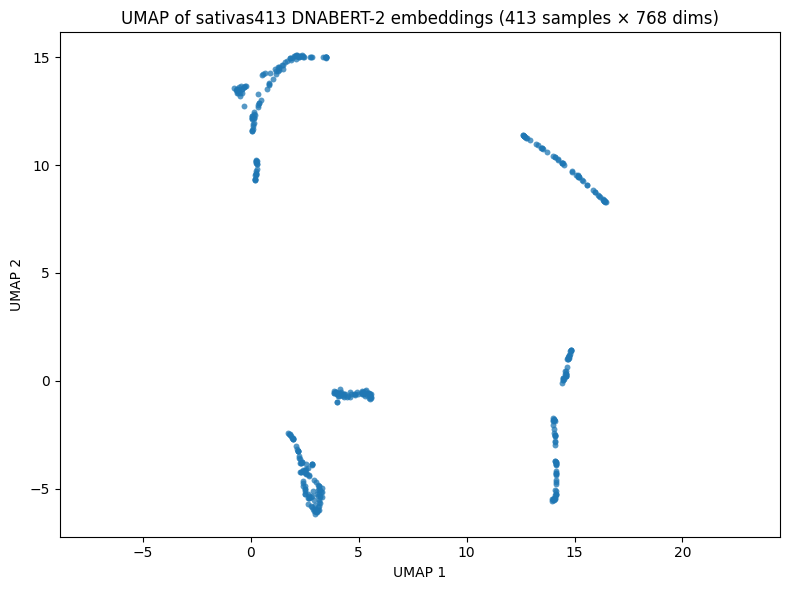